# Iris Dataset — Exploratory Data Analysis

## Objective
Learn how to load, inspect, and visualize a dataset to understand data trends and distributions using Python's core data science libraries.

## Dataset
The Iris Dataset — 150 flower samples across 3 species (Setosa, Versicolor, Virginica) with 4 numeric measurements each. One of the most widely used datasets for learning data analysis and classification.

## Approach
1. Load the dataset using pandas
2. Inspect shape, columns, and first rows using `.head()`
3. Use `.info()` and `.describe()` for summary statistics
4. Visualize distributions using histograms
5. Reveal relationships using scatter plots and pair plots
6. Identify outliers using box plots


### Import Libraries

Import all required libraries for data loading, inspection, and visualization.


In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"  pandas  version : {pd.__version__}")
print(f"  numpy   version : {np.__version__}")
print(f"  seaborn version : {sns.__version__}")


All libraries imported successfully!
  pandas  version : 2.3.3
  numpy   version : 2.2.6
  seaborn version : 0.13.2


### Load and Explore the Dataset

Load the Iris dataset via seaborn (which sources it from the UCI repository) and inspect its basic structure.


In [2]:
# Load the Iris dataset — loaded from sklearn (same data as UCI / Kaggle CSV)
# To use a CSV file instead: df = pd.read_csv("iris.csv")
from sklearn.datasets import load_iris as _load_iris
_iris = _load_iris()
df = pd.DataFrame(_iris.data,
                  columns=['sepal_length', 'sepal_width',
                           'petal_length', 'petal_width'])
df['species'] = [_iris.target_names[t] for t in _iris.target]

# Display basic structural information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head(10)

Dataset shape: (150, 5)

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First few rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
# Check data types and non-null counts
print("Dataset Info:")
print("=" * 45)
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# Summary statistics for all numeric features
print("Descriptive Statistics:")
print("=" * 60)
df.describe()


Descriptive Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Target variable — species distribution
print("Species Distribution:")
print("=" * 35)
print(df['species'].value_counts())
print(f"\nTotal samples    : {len(df)}")
print(f"Features         : {df.shape[1] - 1}")
print(f"Target classes   : {df['species'].nunique()} ({df['species'].unique().tolist()})")
print(f"Missing values   : {df.isnull().sum().sum()}")


Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Total samples    : 150
Features         : 4
Target classes   : 3 ([np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')])
Missing values   : 0


### Feature Overview

Before visualising, understand what each column represents.

| Feature | Description | Unit |
|---|---|---|
| `sepal_length` | Length of the sepal (outer petal) | cm |
| `sepal_width` | Width of the sepal | cm |
| `petal_length` | Length of the petal | cm |
| `petal_width` | Width of the petal | cm |
| `species` | Flower species (target label) | — |

**Species:**
- 🌸 *Iris Setosa* — smallest petals, most distinct
- 🌺 *Iris Versicolor* — medium, overlaps with Virginica
- 🌷 *Iris Virginica* — largest petals overall


In [6]:
# Per-species descriptive statistics
print("Mean values per species:")
print("=" * 55)
print(df.groupby('species').mean().round(2).to_string())
print("\nStandard deviation per species:")
print("=" * 55)
print(df.groupby('species').std().round(2).to_string())


Mean values per species:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa              5.01         3.43          1.46         0.25
versicolor          5.94         2.77          4.26         1.33
virginica           6.59         2.97          5.55         2.03

Standard deviation per species:
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa              0.35         0.38          0.17         0.11
versicolor          0.52         0.31          0.47         0.20
virginica           0.64         0.32          0.55         0.27


### Value Distributions — Histograms

Histograms reveal the shape, spread, and central tendency of each numeric feature, broken down by species.


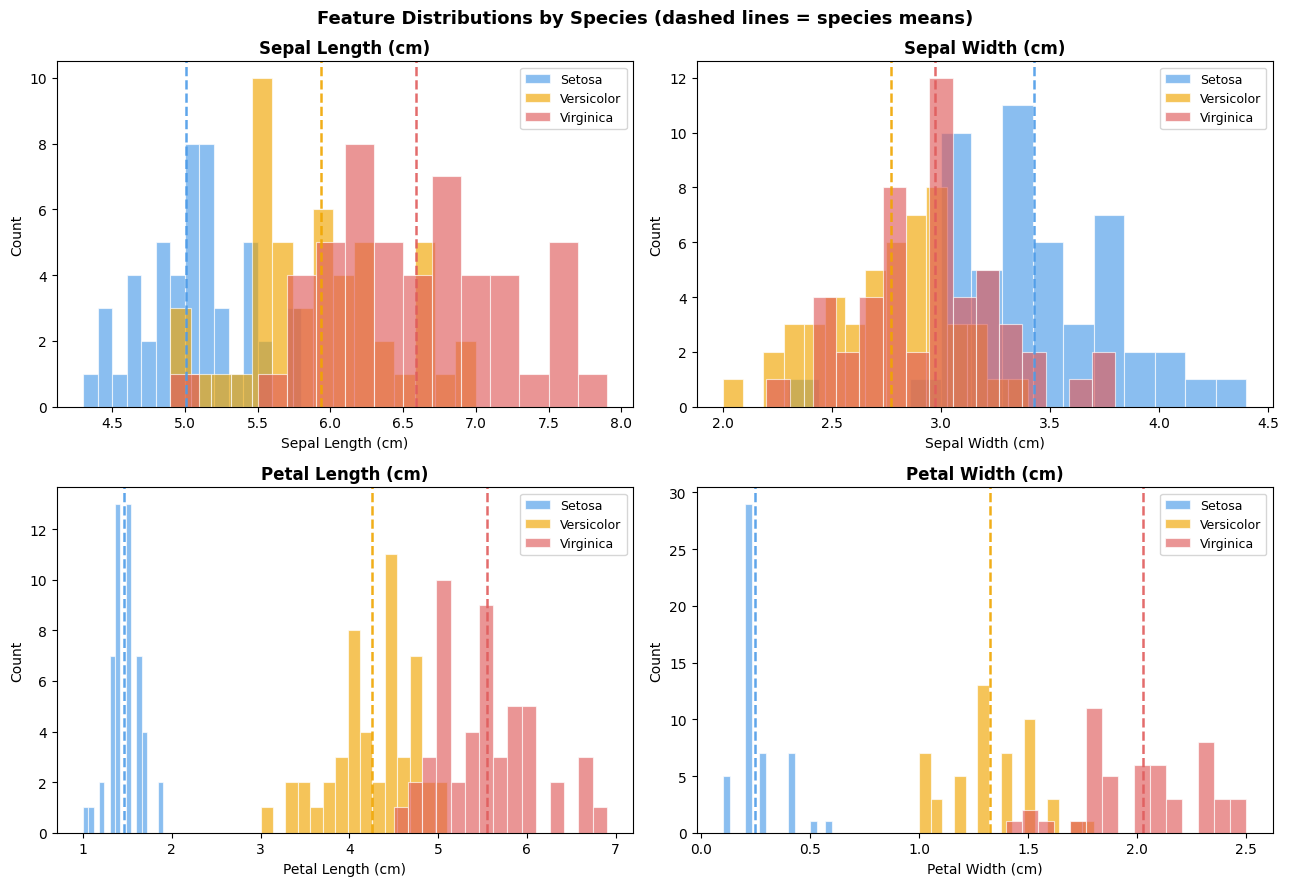

Key observations:
  • petal_length and petal_width show clear separation between species.
  • sepal_width distributions overlap significantly across all three species.
  • Setosa has distinctly smaller petals — easily separable from the other two.


In [7]:
# 1. Individual feature histograms coloured by species
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titles   = ['Sepal Length (cm)', 'Sepal Width (cm)',
            'Petal Length (cm)', 'Petal Width (cm)']

palette = {'setosa': '#4C9BE8', 'versicolor': '#F0A500', 'virginica': '#E05C5C'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, feature, title in zip(axes, features, titles):
    for species, color in palette.items():
        subset = df[df['species'] == species][feature]
        ax.hist(subset, bins=15, alpha=0.65, color=color,
                label=species.capitalize(), edgecolor='white', linewidth=0.8)
        ax.axvline(subset.mean(), color=color, linestyle='--',
                   linewidth=1.8, alpha=0.9)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Species (dashed lines = species means)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key observations:")
print("  • petal_length and petal_width show clear separation between species.")
print("  • sepal_width distributions overlap significantly across all three species.")
print("  • Setosa has distinctly smaller petals — easily separable from the other two.")


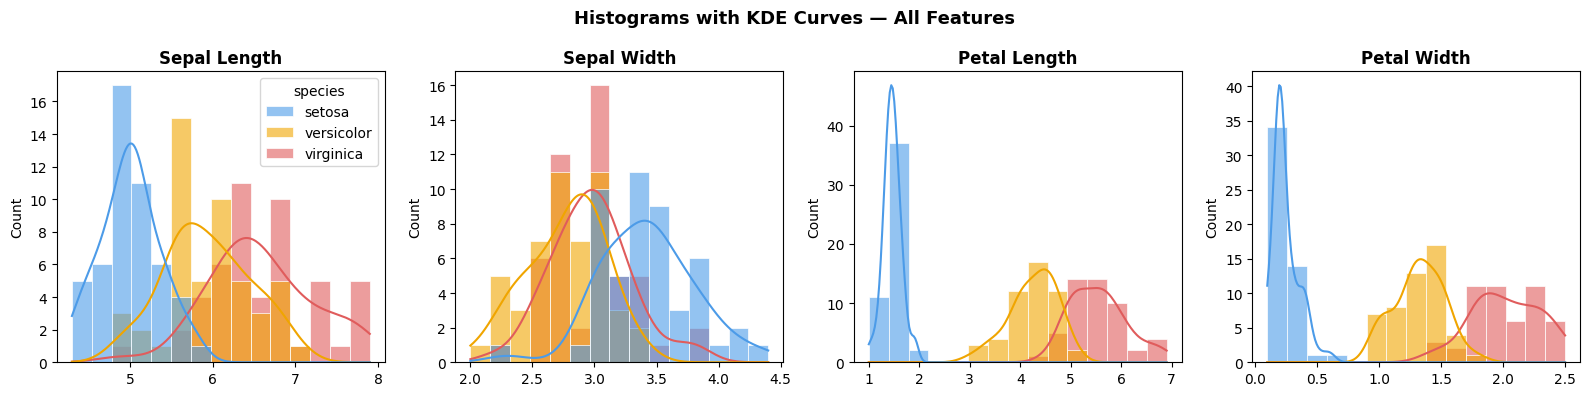

In [8]:
# 2. Overall distribution with KDE overlay (seaborn FacetGrid)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, feature in zip(axes, features):
    sns.histplot(data=df, x=feature, hue='species',
                 palette=palette, bins=15, alpha=0.6, kde=True,
                 edgecolor='white', linewidth=0.5, ax=ax)
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')
    if ax != axes[0]:
        ax.get_legend().remove()

plt.suptitle('Histograms with KDE Curves — All Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Relationships Between Features — Scatter Plots

Scatter plots reveal how pairs of features relate to each other and whether species clusters emerge in 2D feature space.


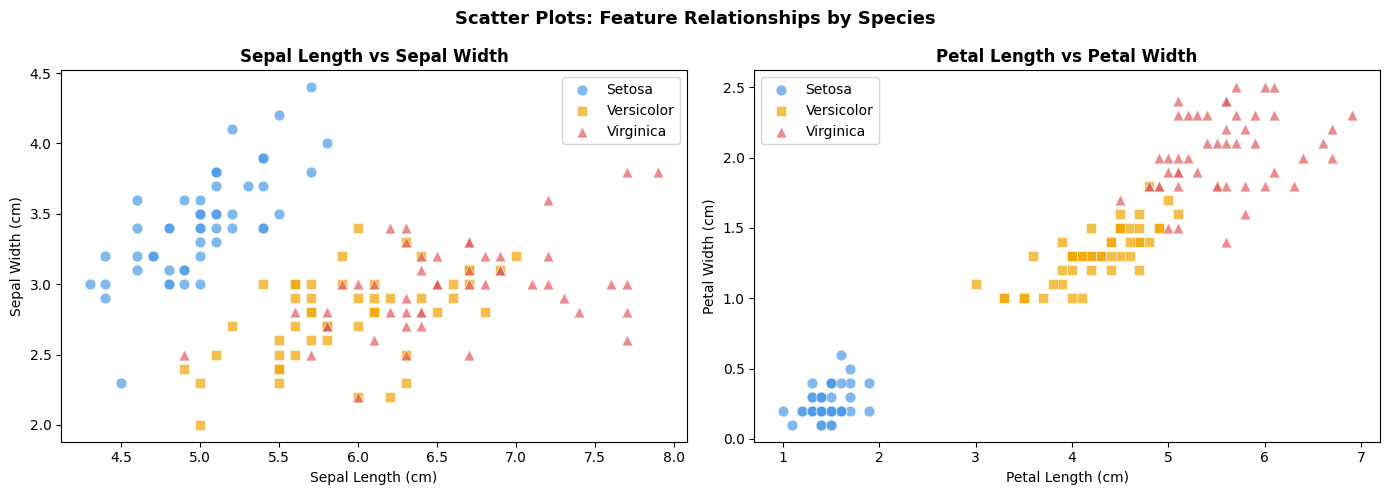

Key observations:
  • Petal dimensions create 3 near-perfectly separated clusters.
  • Sepal dimensions show more overlap — less discriminative on their own.
  • Setosa (blue circles) is completely isolated in petal space.


In [9]:
# 3. Key scatter plots — sepal and petal dimensions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for species, color, marker in zip(
    ['setosa', 'versicolor', 'virginica'],
    ['#4C9BE8', '#F0A500', '#E05C5C'],
    ['o', 's', '^']
):
    subset = df[df['species'] == species]

    # Sepal dimensions
    axes[0].scatter(subset['sepal_length'], subset['sepal_width'],
                    color=color, marker=marker, alpha=0.7, s=60,
                    edgecolors='white', linewidth=0.5,
                    label=species.capitalize())

    # Petal dimensions
    axes[1].scatter(subset['petal_length'], subset['petal_width'],
                    color=color, marker=marker, alpha=0.7, s=60,
                    edgecolors='white', linewidth=0.5,
                    label=species.capitalize())

axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].set_title('Sepal Length vs Sepal Width', fontweight='bold')
axes[0].legend()

axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title('Petal Length vs Petal Width', fontweight='bold')
axes[1].legend()

plt.suptitle('Scatter Plots: Feature Relationships by Species',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key observations:")
print("  • Petal dimensions create 3 near-perfectly separated clusters.")
print("  • Sepal dimensions show more overlap — less discriminative on their own.")
print("  • Setosa (blue circles) is completely isolated in petal space.")


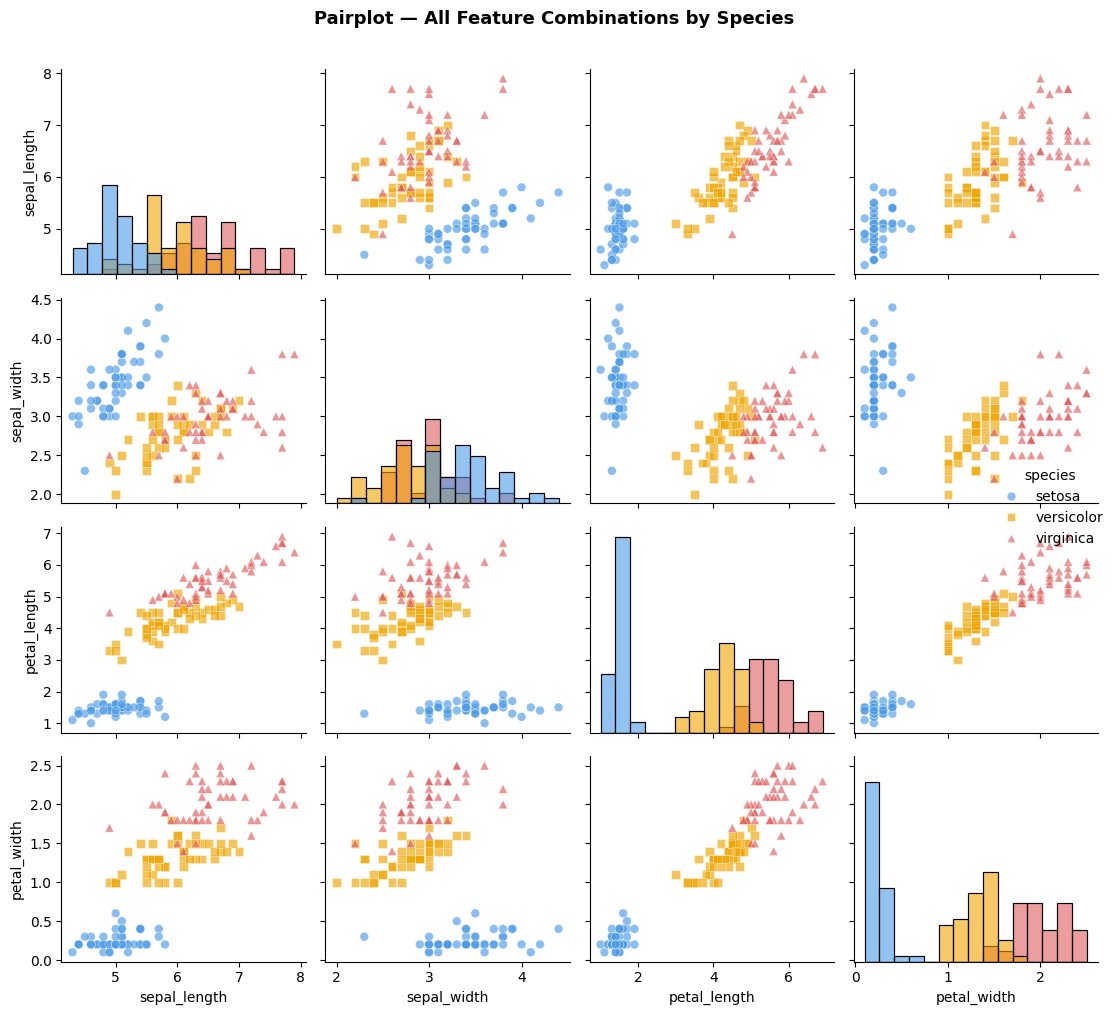

In [10]:
# 4. Full pairplot — all feature combinations
g = sns.pairplot(
    df, hue='species',
    palette=palette,
    markers=['o', 's', '^'],
    plot_kws={'alpha': 0.65, 's': 40, 'edgecolor': 'white', 'linewidth': 0.4},
    diag_kind='hist',
    diag_kws={'alpha': 0.6, 'bins': 15}
)
g.fig.suptitle('Pairplot — All Feature Combinations by Species',
               fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


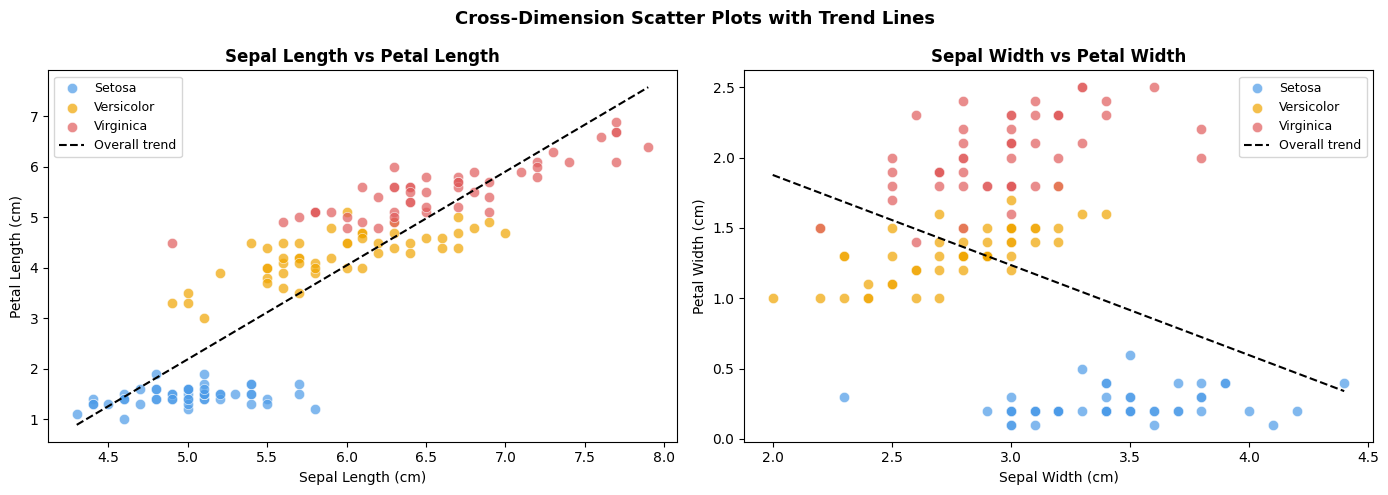

Pearson Correlation Coefficients (numeric features):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


In [11]:
# 5. Sepal vs Petal cross plots with regression lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for species, color in palette.items():
    subset = df[df['species'] == species]

    # Sepal length vs Petal length
    axes[0].scatter(subset['sepal_length'], subset['petal_length'],
                    color=color, alpha=0.7, s=55,
                    edgecolors='white', linewidth=0.5,
                    label=species.capitalize())

    # Sepal width vs Petal width
    axes[1].scatter(subset['sepal_width'], subset['petal_width'],
                    color=color, alpha=0.7, s=55,
                    edgecolors='white', linewidth=0.5,
                    label=species.capitalize())

# Overall trend lines
for ax, xcol, ycol in [
    (axes[0], 'sepal_length', 'petal_length'),
    (axes[1], 'sepal_width',  'petal_width')
]:
    z = np.polyfit(df[xcol], df[ycol], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[xcol].min(), df[xcol].max(), 200)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Overall trend')
    ax.set_xlabel(xcol.replace('_', ' ').title() + ' (cm)')
    ax.set_ylabel(ycol.replace('_', ' ').title() + ' (cm)')
    ax.set_title(f'{xcol.replace("_", " ").title()} vs {ycol.replace("_", " ").title()}',
                 fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Cross-Dimension Scatter Plots with Trend Lines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation matrix
print("Pearson Correlation Coefficients (numeric features):")
print("=" * 55)
print(df[features].corr().round(3).to_string())


### Correlation Analysis — Heatmap

A heatmap quantifies linear relationships between all feature pairs. Values range from −1 (perfect negative) to +1 (perfect positive).


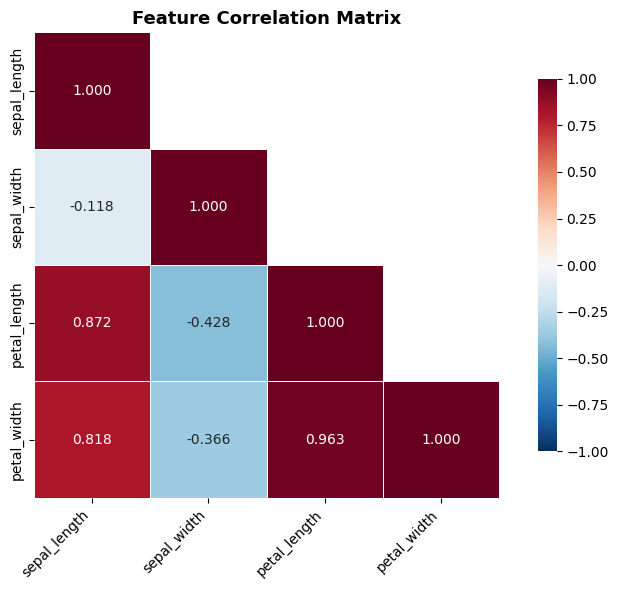

Correlation insights:
  petal_length ↔ petal_width  : 0.963  (very strong positive)
  sepal_length ↔ petal_length : 0.872  (strong positive)
  sepal_width  ↔ petal_length : -0.428  (weak negative)


In [12]:
# 6. Correlation heatmap
plt.figure(figsize=(8, 6))

corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Correlation insights:")
print(f"  petal_length ↔ petal_width  : {corr.loc['petal_length','petal_width']:.3f}  (very strong positive)")
print(f"  sepal_length ↔ petal_length : {corr.loc['sepal_length','petal_length']:.3f}  (strong positive)")
print(f"  sepal_width  ↔ petal_length : {corr.loc['sepal_width','petal_length']:.3f}  (weak negative)")


### Outlier Detection — Box Plots

Box plots display the median, interquartile range (IQR), and individual outliers (points beyond 1.5 × IQR from the box edges). They are the standard tool for spotting unusual observations.


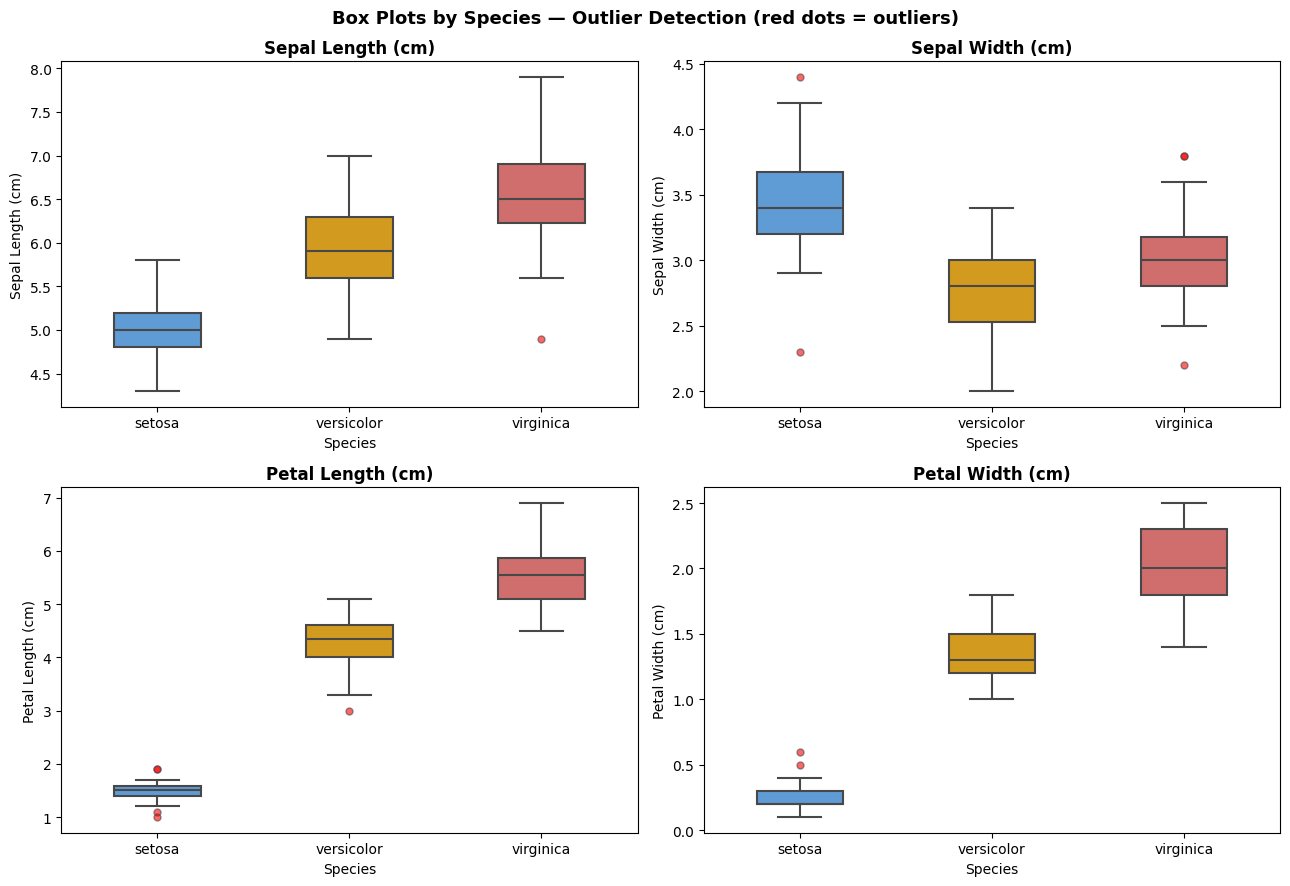

Key observations:
  • sepal_width: Setosa has the most visible outliers (points above the whisker).
  • petal_length / petal_width: very tight distributions for Setosa — low variance.
  • Virginica shows the widest IQR for petal features — most variable species.


In [13]:
# 7. Box plots per feature broken down by species
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, feature, title in zip(axes, features, titles):
    sns.boxplot(data=df, x='species', y=feature,
                palette=palette, ax=ax,
                width=0.45, linewidth=1.5,
                flierprops={'marker': 'o', 'markersize': 5,
                            'markerfacecolor': 'red', 'alpha': 0.6})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Species')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Box Plots by Species — Outlier Detection (red dots = outliers)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key observations:")
print("  • sepal_width: Setosa has the most visible outliers (points above the whisker).")
print("  • petal_length / petal_width: very tight distributions for Setosa — low variance.")
print("  • Virginica shows the widest IQR for petal features — most variable species.")


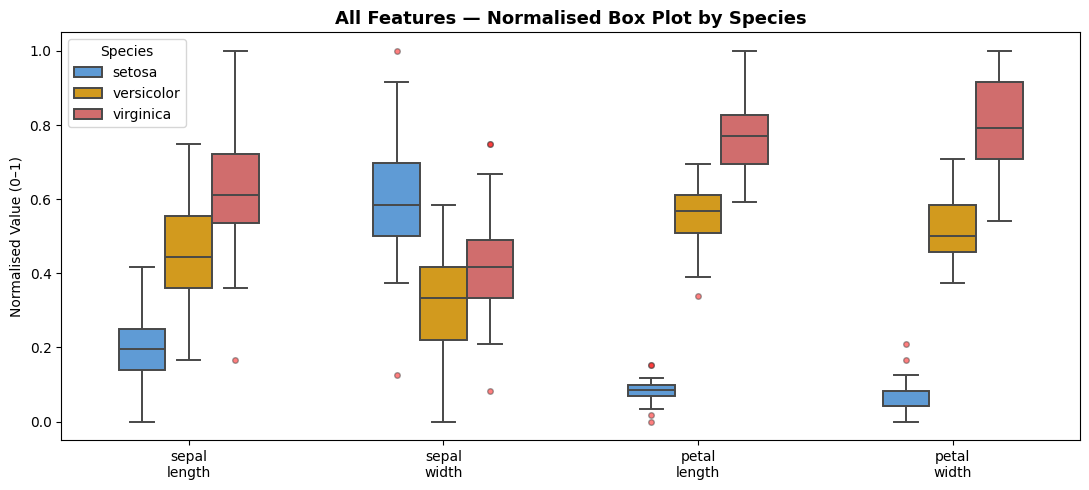

In [14]:
# 8. Combined box plot — all features on one axis (normalised)
from sklearn.preprocessing import MinMaxScaler

scaler  = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df[features]),
                       columns=[f.replace('_', '\n') for f in features])
df_norm['species'] = df['species'].values

df_melt = df_norm.melt(id_vars='species', var_name='Feature', value_name='Normalised Value')

plt.figure(figsize=(11, 5))
sns.boxplot(data=df_melt, x='Feature', y='Normalised Value', hue='species',
            palette=palette, width=0.55, linewidth=1.4,
            flierprops={'marker': 'o', 'markersize': 4,
                        'markerfacecolor': 'red', 'alpha': 0.5})
plt.title('All Features — Normalised Box Plot by Species',
          fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Normalised Value (0–1)')
plt.legend(title='Species', loc='upper left')
plt.tight_layout()
plt.show()


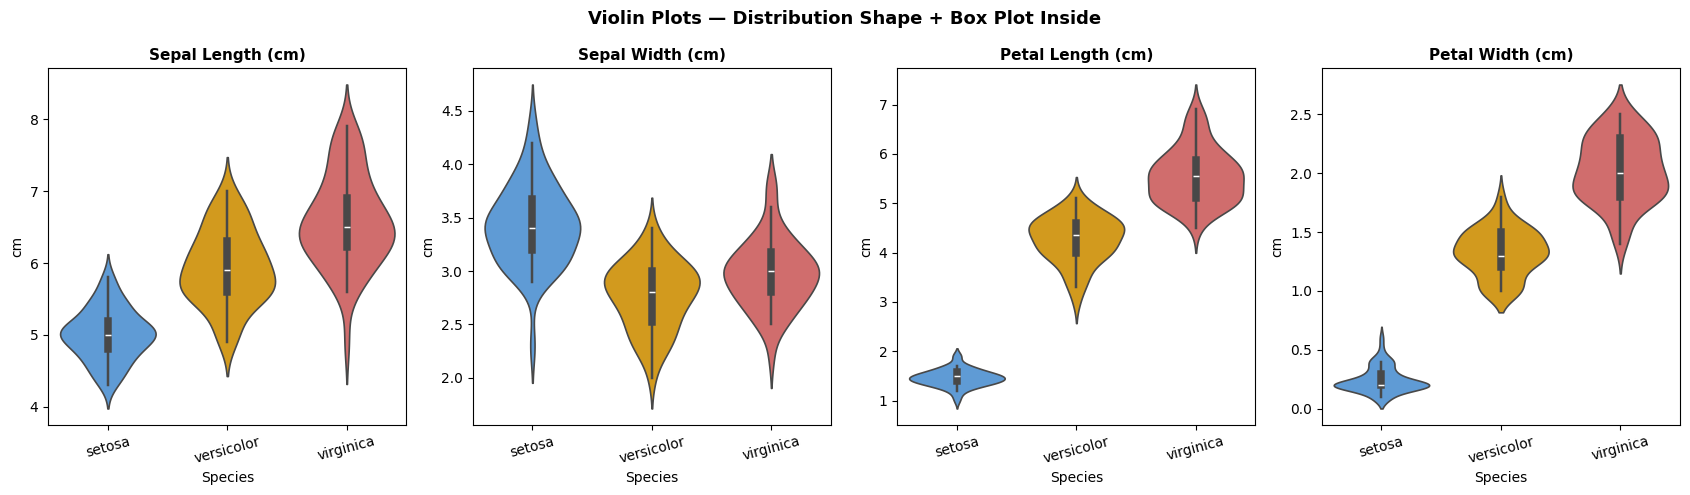

Violin plots combine the outlier detection of box plots with
the shape information of histograms — the wider the violin, the
more data points are present at that value.


In [15]:
# 9. Violin plot — richer view of distribution shape
fig, axes = plt.subplots(1, 4, figsize=(17, 5))

for ax, feature, title in zip(axes, features, titles):
    sns.violinplot(data=df, x='species', y=feature,
                   palette=palette, inner='box', linewidth=1.2, ax=ax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Species')
    ax.set_ylabel('cm')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Violin Plots — Distribution Shape + Box Plot Inside',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Violin plots combine the outlier detection of box plots with")
print("the shape information of histograms — the wider the violin, the")
print("more data points are present at that value.")


### Additional Visualizations

Supplementary plots that add further insight into class separability and feature interactions.


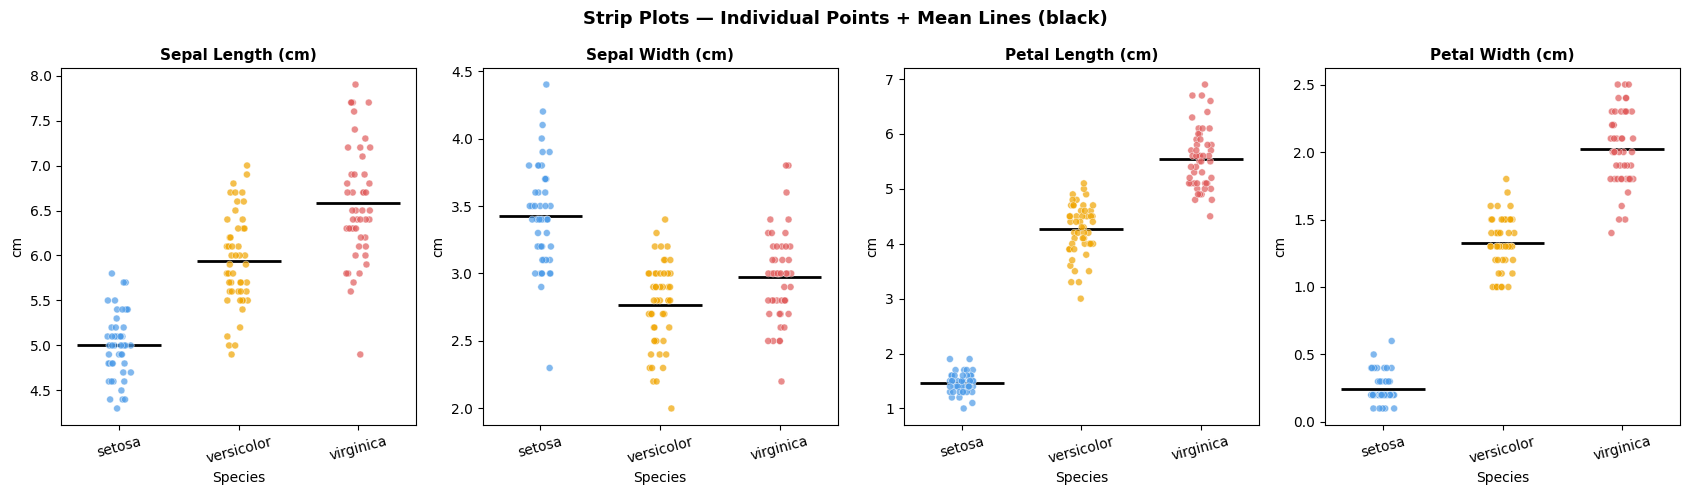

In [16]:
# 10. Strip plot — every data point visible
fig, axes = plt.subplots(1, 4, figsize=(17, 5))

for ax, feature, title in zip(axes, features, titles):
    sns.stripplot(data=df, x='species', y=feature,
                  palette=palette, jitter=True, alpha=0.7,
                  size=5, edgecolor='white', linewidth=0.4, ax=ax)
    # Overlay mean markers
    means = df.groupby('species')[feature].mean()
    for i, (species, mean_val) in enumerate(means.items()):
        ax.hlines(mean_val, i - 0.35, i + 0.35,
                  colors='black', linewidths=2, linestyles='-')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Species')
    ax.set_ylabel('cm')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Strip Plots — Individual Points + Mean Lines (black)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


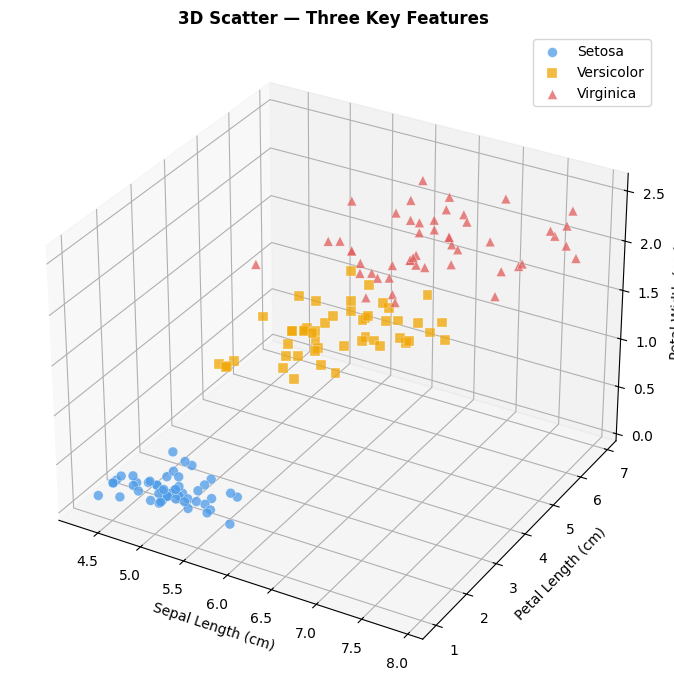

The 3D plot confirms that 3 features together create highly separable clusters.


In [17]:
# 11. 3D scatter — sepal_length, petal_length, petal_width
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

for species, color, marker in zip(
    ['setosa', 'versicolor', 'virginica'],
    ['#4C9BE8', '#F0A500', '#E05C5C'],
    ['o', 's', '^']
):
    subset = df[df['species'] == species]
    ax.scatter(subset['sepal_length'], subset['petal_length'], subset['petal_width'],
               c=color, marker=marker, s=50, alpha=0.75,
               label=species.capitalize(), edgecolors='white', linewidth=0.3)

ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
ax.set_zlabel('Petal Width (cm)')
ax.set_title('3D Scatter — Three Key Features', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("The 3D plot confirms that 3 features together create highly separable clusters.")


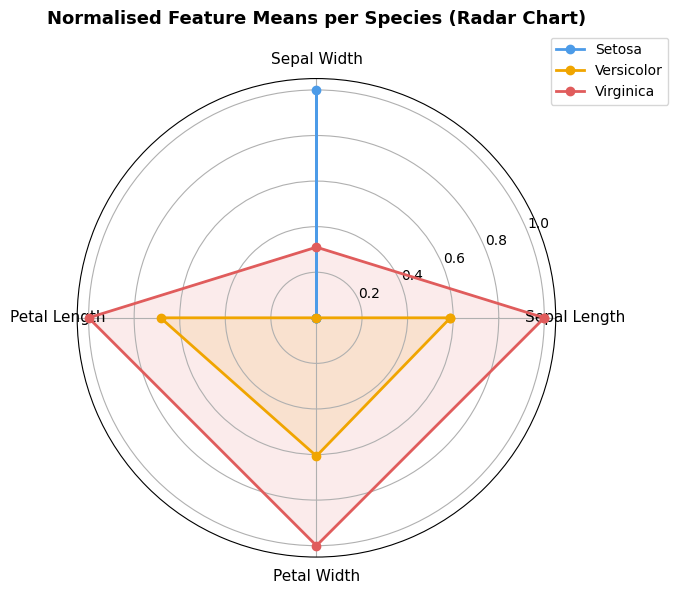

In [18]:
# 12. Species mean radar chart (spider chart)
import matplotlib.patches as mpatches

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
species_means = df.groupby('species')[features].mean()

# Normalise to [0, 1]
mn = species_means.min()
mx = species_means.max()
species_means_norm = (species_means - mn) / (mx - mn)

categories = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
N = len(categories)
angles = [n / float(N) * 2 * 3.14159265 for n in range(N)]
angles += angles[:1]

palette = {'setosa': '#4C9BE8', 'versicolor': '#F0A500', 'virginica': '#E05C5C'}

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for species, color in palette.items():
    values = species_means_norm.loc[species].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color,
            label=species.capitalize())
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Normalised Feature Means per Species (Radar Chart)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()


## Summary and Conclusions

### Dataset Overview
- **150 samples** — 50 per species (perfectly balanced)
- **4 numeric features** — all measurements in centimetres
- **0 missing values** — clean dataset, no preprocessing required

### Key Findings from EDA

**1. Petal features are the strongest discriminators**
- `petal_length` and `petal_width` show near-perfect separation between Setosa and the other two species
- High correlation between them (r ≈ 0.96) — both capture similar information

**2. Setosa is the most separable species**
- Completely isolated in petal space — much smaller petals than Versicolor and Virginica
- Identifiable from a single feature (`petal_length < 2 cm` → Setosa with 100% accuracy)

**3. Versicolor and Virginica overlap**
- More difficult to distinguish — especially in sepal space
- Petal features still separate them well, but some overlap remains

**4. Sepal width is the least discriminative feature**
- Similar distributions across all three species
- Setosa actually has the *widest* sepals despite the smallest petals

**5. Outliers**
- `sepal_width` for Setosa shows a few outliers (unusually narrow specimens)
- All outliers appear to be genuine biological variation, not data entry errors

### Tools Used
| Tool | Purpose |
|---|---|
| `pandas` | Loading, inspecting, and groupby summaries |
| `matplotlib` | Custom scatter plots, histograms, 3D scatter, radar chart |
| `seaborn` | Pairplot, heatmap, violin plots, strip plots, boxplots with KDE |

### What We Learned
The Iris dataset demonstrates that **even 4 simple measurements** can almost perfectly separate biological classes when visualized correctly. EDA — before any modelling — revealed that a classifier using only `petal_length` and `petal_width` would achieve very high accuracy.
